Dataset	Mean	Std Dev	Kurtosis
A	14.00	3.16	1.70
B	14.00	4.00	1.25
C	14.00	5.10	1.43
D	14.00	3.16	1.70


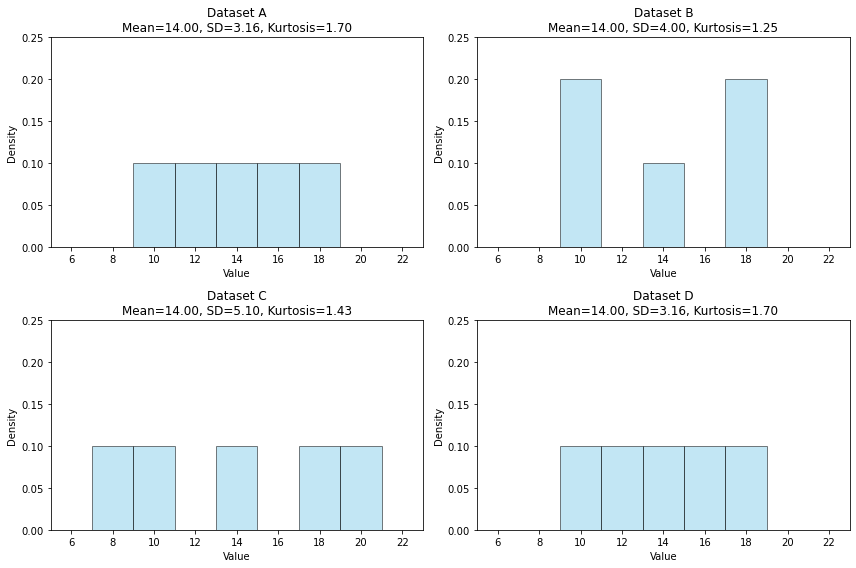

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# Example datasets
dataset_A = np.array([10, 12, 14, 16, 18])
dataset_B = np.array([10, 10, 14, 18, 18])
dataset_C = np.array([8, 10, 14, 18, 20])
dataset_D = np.array([10, 12, 14, 16, 18])

datasets = {
    'A': dataset_A,
    'B': dataset_B,
    'C': dataset_C,
    'D': dataset_D
}

# Calculate statistics
print("Dataset\tMean\tStd Dev\tKurtosis")
for label, data in datasets.items():
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)  # sample std dev
    kurt_val = kurtosis(data, fisher=False)  # Pearson kurtosis (normal=3)
    print(f"{label}\t{mean_val:.2f}\t{std_val:.2f}\t{kurt_val:.2f}")

# Plot distributions using histograms with kernel density estimate overlay
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (label, data) in enumerate(datasets.items()):
    axs[i].hist(data, bins=np.arange(7, 22, 2), density=True, alpha=0.5, color='skyblue', edgecolor='black')
    axs[i].set_title(f"Dataset {label}\nMean={np.mean(data):.2f}, SD={np.std(data, ddof=1):.2f}, Kurtosis={kurtosis(data, fisher=False):.2f}")
    axs[i].set_xlim(5, 23)
    axs[i].set_ylim(0, 0.25)
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Density")

plt.tight_layout()
plt.show()



In [99]:
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

def compute_time_based_skewness(event):

    values = np.array(event).flatten()

    n = len(values)
    positions = np.linspace(0, 1, n)
    total = values.sum()

    # Center of mass
    t_cg = np.sum(positions * values) / total

    # Standard deviation
    sigma_t = np.sqrt(np.sum(((positions - t_cg) ** 2) * values) / total)

    # Skewness
    skew = np.sum(((positions - t_cg) ** 3) * values) / (total * sigma_t**3)

    return skew


def compute_time_based_kurtosis(event):
    values = np.array(event).flatten()
    n = len(values)
    
    # Make time axis from 0 to 1 (fractional position)
    positions = np.linspace(0, 1, n)

    total = values.sum()

    # Center of gravity (t_cg in [0, 1])
    t_cg = np.sum(positions * values) / total

    # Standard deviation in fractional time
    sigma_t = np.sqrt(np.sum(((positions - t_cg) ** 2) * values) / total)

    # Kurtosis in fractional time
    kurt = np.sum(((positions - t_cg) ** 4) * values) / (total * sigma_t**4)

    return kurt


def compute_time_based_std_simple(event):
    values = np.array(event).flatten()

    n = len(values)
    positions = np.linspace(0, 1, n)
    total = values.sum()

    # Center of mass (mean time, weighted by rainfall)
    t_cg = np.sum(positions * values) / total

    # Time-based standard deviation (weighted)
    sigma_t = np.sqrt(np.sum(((positions - t_cg) ** 2) * values) / total)

    return sigma_t

def gini_coef(series):
    """Compute the Gini coefficient in O(n) time without sorting or large memory allocations."""

    n = len(series)

    series = np.array(series).flatten()

    if n == 0 or np.all(series == 0): 
        return 0  # Handle empty or zero arrays safely

    abs_diffs = np.sum(np.abs(series[:, None] - series))  # Efficient pairwise sum
    mean_value = np.mean(series)

    return abs_diffs / (2 * n**2 * mean_value) if mean_value != 0 else 0


def calculate_pci(precip_series):

    precip_series = np.array(precip_series)

    if precip_series.sum() == 0:
        return 0  # Avoid division by zero, PCI is undefined for zero rainfall

    numerator = np.sum(precip_series**2)
    denominator = np.sum(precip_series)**2

    pci = (numerator / denominator) * 100
    return pci    

def high_low_zone_indicators(series):
    temp_res=5
    res_hours = temp_res / 60  # convert to hours

    # Convert mm/timestep to mm/hour
    series_hr = np.array(series) / res_hours

    mean_intensity = series_hr.mean()
    indices_above = np.where(series_hr > mean_intensity)[0]
    indices_below = np.where(series_hr < mean_intensity)[0]

    # Proportion of time in high/low intensity zones
    frac_time_in_high_intensity_zone = len(indices_above) / len(series) * 100
    frac_time_in_low_intensity_zone = len(indices_below) / len(series) * 100

    # Fraction of rainfall in high intensity zone
    frac_rain_in_high_intensity_zone = series_hr[indices_above].sum() / series_hr.sum() * 100 if series_hr.sum() > 0 else 0

    # Mean intensity in high intensity zone
    mean_intensity_high_intensity_zone = (
        series_hr[indices_above].mean() if len(indices_above) > 0 else 0
    )

    return np.array([
        frac_time_in_high_intensity_zone,
        frac_time_in_low_intensity_zone,
        frac_rain_in_high_intensity_zone,
        mean_intensity_high_intensity_zone
    ])


In [115]:
# event1 = [1,1,1,1,1,30,1,1,1,1]
# event2 = [1,1,1,1,1,30,29,1,1,1]
# event3 = [0,0,0,0,0,30,0,0,0,0]
# event3 = [1,1,1,1,1,1,1,1,1,1]

# event4 = np.array(event1) *2 
# event5 = np.array(event2) *2
# event6 = [0,0,0,0,0,60,0,0,0,0]

# event7 = [1,1,1,1,1,30,1,1,1,1,1,1,1,1,1,1]
# event8 = [1,1,1,1,1,30,29,1,1,1,1,1,1,1,1,1]
# event9 = [0,0,0,0,0,30,0,0,0,0]


event1 = [1,1,2,2,2,1,1.1, 1.1, 1.1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1] #long durtion, low intensity
event2 = [1,2,3,6,7,4,2,1] # short durtion, high intensity
event3 = [0,0,0,0,0,30,0,0,0,0]


def do_it(events, names):
    metrics = {
        "Length": [],
        "Peak": [],
        "Total":[],
        "PMR": [],
        "Time-based Std": [],
        "Skewness": [],
        "Kurtosis": [],
        "Gini": [],
        "PCI": [],
        "CV":[],
        "% time in HIZ": [],
        "% time in LIZ": [],
        "% rain in HIZ": [],        
        "Mean": [],
        "Std": [],        
        "Mean intensity HIZ": [],
        "(T) skewness": [],
        "(T) kurtosis": [],
    }

    for e in events:
        metrics["Length"].append(len(e))
        metrics["Peak"].append(np.max(e))
        metrics["Total"].append(np.sum(e))        
        metrics["PMR"].append(np.max(e) / np.mean(e))
        metrics["Time-based Std"].append(compute_time_based_std_simple(e))
        metrics["Skewness"].append(skew(e))
        metrics["Kurtosis"].append(kurtosis(e, fisher=True))
        metrics["Gini"].append(gini_coef(e))
        metrics["PCI"].append(calculate_pci(e))
        metrics['CV'].append(np.std(e)/ np.mean(e))
        metrics["% time in HIZ"].append(high_low_zone_indicators(e)[0])
        metrics["% time in LIZ"].append(high_low_zone_indicators(e)[1])
        metrics["% rain in HIZ"].append(high_low_zone_indicators(e)[2])        
        metrics["Mean"].append(np.mean(e))
        metrics["Std"].append(np.std(e)) 
        metrics["Mean intensity HIZ"].append(high_low_zone_indicators(e)[3])
        metrics["(T) skewness"].append(compute_time_based_skewness(e))     
        metrics["(T) kurtosis"].append(compute_time_based_kurtosis(e))
            
    # Format and print table
    df = pd.DataFrame(metrics, index=names)
    pd.options.display.float_format = "{:.2f}".format
    
    return df

df = do_it([event1, event2, event3],  ["Event 1", "Event 2", "Event 3", ])
df2= do_it([event4, event5, event6],  [ "Event 4", "Event 5", "Event 6", ])
df3= do_it([event7, event8, event9],  [ "Event 7", "Event 8", "Event 9", ])
df

/nfs/a321/gy17m2a/anaconda_install/anaconda3/envs/ukcp18/lib/python3.7/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in double_scalars
/nfs/a321/gy17m2a/anaconda_install/anaconda3/envs/ukcp18/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in double_scalars


,Length,Peak,Total,PMR,Time-based Std,Skewness,Kurtosis,Gini,PCI,CV,% time in HIZ,% time in LIZ,% rain in HIZ,Mean,Std,Mean intensity HIZ,(T) skewness,(T) kurtosis
Event 1,29,2.00,32.30,1.80,0.31,2.56,4.63,0.09,3.70,0.27,10.34,89.66,18.58,1.11,0.30,24.00,0.18,1.72
Event 2,8,7.00,26.00,2.15,0.23,0.63,-1.02,0.36,17.75,0.65,37.50,62.50,65.38,3.25,2.11,68.00,-0.11,2.75
Event 3,10,30.00,30.00,10.00,0.00,2.67,5.11,0.90,100.00,3.00,10.00,90.00,100.00,3.00,9.00,360.00,NaN,NaN


In [105]:
df2

,Length,Peak,Total,PMR,Time-based Std,Skewness,Kurtosis,Gini,PCI,CV,% time in HIZ,% time in LIZ,% rain in HIZ,Mean,Std,Mean intensity HIZ,(T) skewness,(T) kurtosis
Event 4,10,60,78,7.69,0.16,2.67,5.11,0.67,59.76,2.23,10.00,90.00,76.92,7.80,17.40,720.00,-0.75,7.00
Event 5,10,60,134,4.48,0.14,1.50,0.26,0.68,38.96,1.70,20.00,80.00,88.06,13.40,22.80,708.00,-1.58,9.53
Event 6,10,60,60,10.00,0.00,2.67,5.11,0.90,100.00,3.00,10.00,90.00,100.00,6.00,18.00,720.00,NaN,NaN


In [110]:
df3

,Length,Peak,Total,PMR,Time-based Std,Skewness,Kurtosis,Gini,PCI,CV,% time in HIZ,% time in LIZ,% rain in HIZ,Mean,Std,Mean intensity HIZ,(T) skewness,(T) kurtosis
Event 7,16,30,45,10.67,0.20,3.61,11.07,0.60,45.19,2.50,6.25,93.75,66.67,2.81,7.02,360.00,1.39,5.05
Event 8,16,30,73,6.58,0.16,2.27,3.15,0.68,32.93,2.07,12.50,87.50,80.82,4.56,9.43,354.00,1.72,8.06
Event 9,10,30,30,10.00,0.00,2.67,5.11,0.90,100.00,3.00,10.00,90.00,100.00,3.00,9.00,360.00,NaN,NaN
